# DDPM Forward Diffusion

This notebook implements the forward diffusion process used in Denoising Diffusion Probabilistic Models (DDPM). We study the linear noise schedule, visualize gradual corruption of images, compare it with the cosine schedule, and verify the closed-form forward diffusion equation.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!unzip -q "/content/drive/MyDrive/Week5 SOC/archive (10).zip" -d /content/

replace /content/img_align_celeba/img_align_celeba/000001.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
A
A


In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

# Load one batch of CelebA for visualization
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])


dataset = ImageFolder(
    root="/content/img_align_celeba",
    transform=transform
)

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

x, _ = next(iter(loader))
x = x.to(device)

Using: cpu


## 1. Configure the Diffusion Schedule

We define the number of diffusion timesteps and create either a linear or cosine noise schedule. From the schedule we compute:

- βₜ : noise variance
- αₜ = 1 − βₜ
- ᾱₜ : cumulative signal retained

In [4]:
# ===== CONFIGURATION =====  [PLAY] change any value below and rerun
T = 1000  # [PLAY] try 500, 2000
beta_start = 1e-4  # [PLAY] try 1e-5, 1e-3
beta_end = 0.02  # [PLAY] try 0.01, 0.05
schedule_type = "linear"  # [PLAY] try "cosine"

# ===== DEFINE SCHEDULE =====
def cosine_betas(T, s=0.008):
    t = torch.arange(T + 1, device=device)
    f_t = torch.cos(((t / T + s) / (1 + s)) * torch.pi / 2) ** 2
    alphas_bar = f_t / f_t[0]
    betas = 1 - alphas_bar[1:] / alphas_bar[:-1]
    return torch.clip(betas, max=0.999)

if schedule_type == "linear":
    betas = torch.linspace(beta_start, beta_end, T, device=device)
elif schedule_type == "cosine":
    betas = cosine_betas(T)

# Precompute all alpha values
alphas = 1 - betas
alphas_bar = torch.cumprod(alphas, dim=0)  # ᾱ_t
sqrt_alphas_bar = torch.sqrt(alphas_bar)
sqrt_one_minus_alphas_bar = torch.sqrt(1 - alphas_bar)

print(f"ᾱ_1 = {alphas_bar[0]:.6f}, ᾱ_{T} = {alphas_bar[-1]:.6f}")
print(f"beta_1 = {betas[0]:.6f}, beta_{T} = {betas[-1]:.6f}")

ᾱ_1 = 0.999900, ᾱ_1000 = 0.000040
beta_1 = 0.000100, beta_1000 = 0.020000


## 2. Visualizing the Noise Schedule

The following plots illustrate:

- βₜ (noise added per step)
- ᾱₜ (signal retained)
- 1 − ᾱₜ (noise accumulated)

These plots help understand how the image gradually transitions from clean data to Gaussian noise.

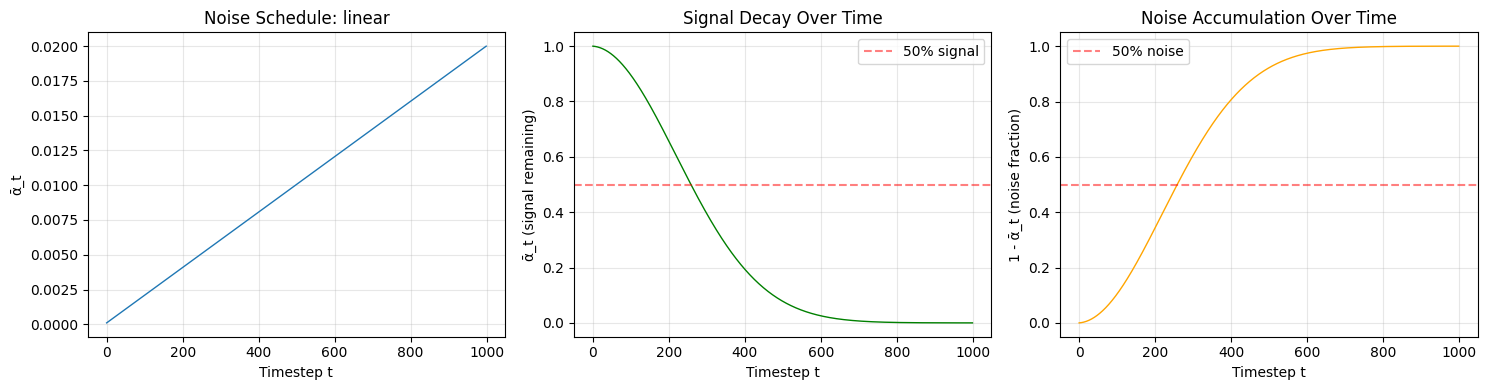

In [5]:
# Plot the schedule — [PLAY] try linear vs cosine
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Beta values across steps
axes[0].plot(betas.cpu(), linewidth=1)
axes[0].set_xlabel("Timestep t")
axes[0].set_ylabel("ᾱ_t")
axes[0].set_title(f"Noise Schedule: {schedule_type}")
axes[0].grid(alpha=0.3)

# Signal retention ᾱ_t
axes[1].plot(alphas_bar.cpu(), linewidth=1, color="green")
axes[1].axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="50% signal")
axes[1].set_xlabel("Timestep t")
axes[1].set_ylabel("ᾱ_t (signal remaining)")
axes[1].set_title("Signal Decay Over Time")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Noise level 1-ᾱ_t
axes[2].plot((1 - alphas_bar).cpu(), linewidth=1, color="orange")
axes[2].axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="50% noise")
axes[2].set_xlabel("Timestep t")
axes[2].set_ylabel("1 - ᾱ_t (noise fraction)")
axes[2].set_title("Noise Accumulation Over Time")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Forward Diffusion Process

The forward diffusion process directly generates a noisy image xₜ from a clean image x₀ using the closed-form equation:

\[
x_t=\sqrt{\bar{\alpha}_t}x_0+\sqrt{1-\bar{\alpha}_t}\epsilon
\]

where ε is sampled from a standard Gaussian distribution.

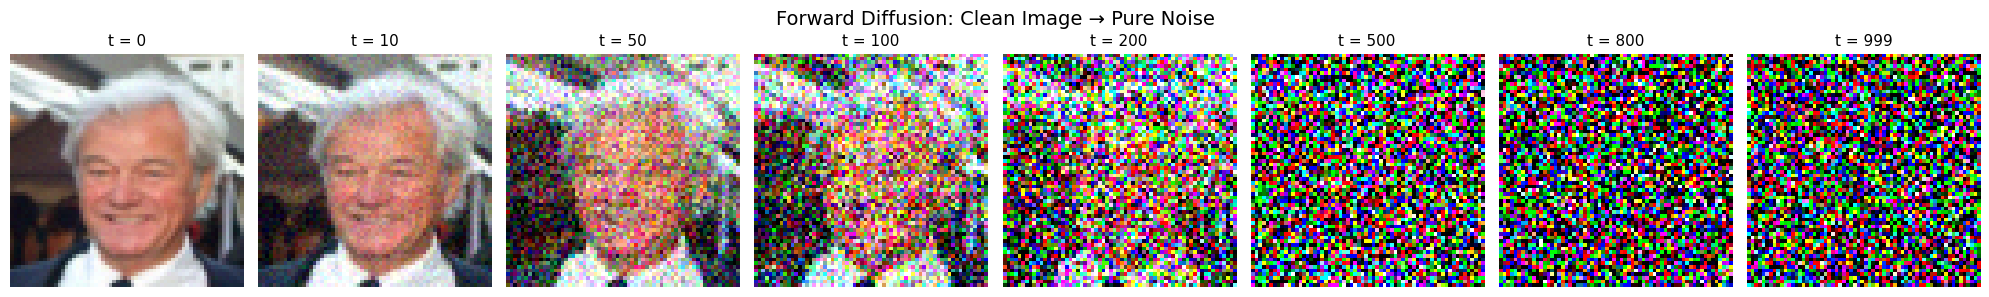

In [6]:
# ===== CLOSED-FORM FORWARD DIFFUSION =====
def forward_diffusion(x0, t, sqrt_alphas_bar, sqrt_one_minus_alphas_bar):
    """
    Jump directly from clean x0 to noisy xt in one step.

    Args:
        x0: clean image [B, C, H, W]
        t: timestep scalar or [B] tensor
    Returns:
        xt: noisy image at step t
        noise: the noise that was added
    """
    noise = torch.randn_like(x0)
    sqrt_alpha_t = sqrt_alphas_bar[t].view(-1, 1, 1, 1)
    sqrt_one_minus_t = sqrt_one_minus_alphas_bar[t].view(-1, 1, 1, 1)
    xt = sqrt_alpha_t * x0 + sqrt_one_minus_t * noise
    return xt, noise


# Sample steps to visualize
sample_steps = [0, 10, 50, 100, 200, 500, 800, 999]
img_idx = 0  # [PLAY] try different faces

x0 = x[img_idx:img_idx+1]  # keep batch dim

fig, axes = plt.subplots(1, len(sample_steps), figsize=(20, 3))
for i, t in enumerate(sample_steps):
    t_tensor = torch.tensor([t], device=device)
    xt, _ = forward_diffusion(x0, t_tensor, sqrt_alphas_bar, sqrt_one_minus_alphas_bar)
    axes[i].imshow(xt[0].cpu().permute(1, 2, 0).clamp(0, 1))
    axes[i].set_title(f"t = {t}", fontsize=11)
    axes[i].axis("off")

plt.suptitle("Forward Diffusion: Clean Image → Pure Noise", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Forward Diffusion Visualization

We apply forward diffusion to the same image at multiple timesteps to observe how the original image gradually becomes dominated by Gaussian noise.

## 5. Signal-to-Noise Ratio (SNR)

The Signal-to-Noise Ratio (SNR) quantifies the amount of signal retained relative to the accumulated noise during the diffusion process.

A high SNR indicates that the image is dominated by useful signal, whereas a low SNR indicates that noise dominates the image.

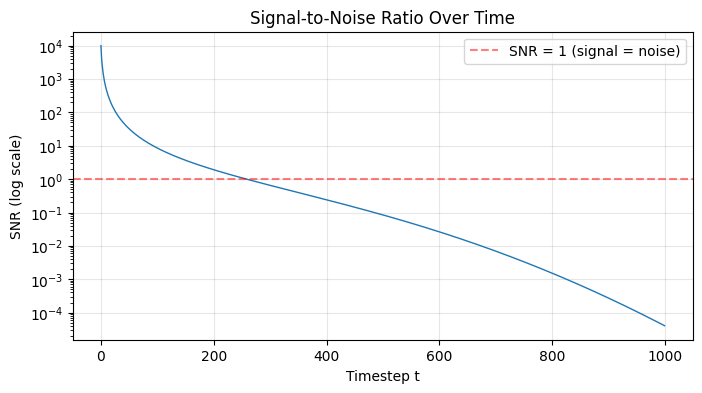

In [7]:
snr = alphas_bar / (1 - alphas_bar + 1e-8)

plt.figure(figsize=(8, 4))
plt.plot(snr.cpu(), linewidth=1)
plt.yscale("log")
plt.axhline(y=1.0, color="red", linestyle="--", alpha=0.5, label="SNR = 1 (signal = noise)")
plt.xlabel("Timestep t")
plt.ylabel("SNR (log scale)")
plt.title("Signal-to-Noise Ratio Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
# Cosine schedule
cosine_betas_tensor = cosine_betas(T)

cosine_alphas = 1 - cosine_betas_tensor
cosine_alpha_bar = torch.cumprod(cosine_alphas, dim=0)

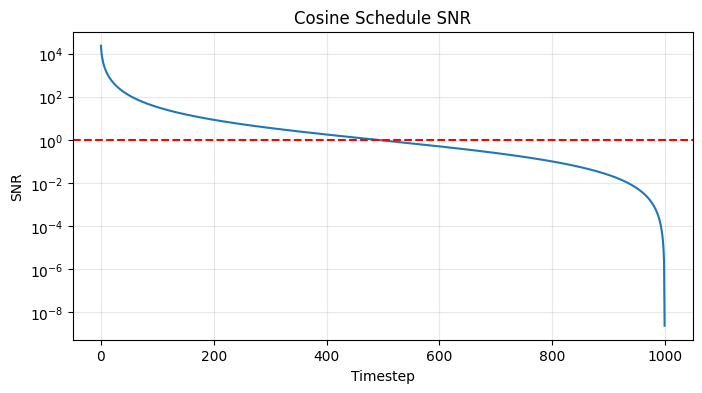

In [9]:
cosine_snr = cosine_alpha_bar / (1 - cosine_alpha_bar + 1e-8)

plt.figure(figsize=(8,4))
plt.plot(cosine_snr.cpu())
plt.yscale("log")
plt.axhline(1,color="red",linestyle="--")
plt.title("Cosine Schedule SNR")
plt.xlabel("Timestep")
plt.ylabel("SNR")
plt.grid(alpha=0.3)
plt.show()

In [10]:
linear_t = torch.argmin(torch.abs(snr-1)).item()
cosine_t = torch.argmin(torch.abs(cosine_snr-1)).item()

print(f"Linear schedule : SNR≈1 at t = {linear_t}")
print(f"Cosine schedule : SNR≈1 at t = {cosine_t}")

Linear schedule : SNR≈1 at t = 258
Cosine schedule : SNR≈1 at t = 495


In [11]:
def cosine_betas(T, s=0.008):
    t = torch.arange(T + 1, device=device)
    f_t = torch.cos(((t / T + s) / (1 + s)) * torch.pi / 2) ** 2
    alphas_bar = f_t / f_t[0]
    betas = 1 - alphas_bar[1:] / alphas_bar[:-1]
    return torch.clip(betas, max=0.999)

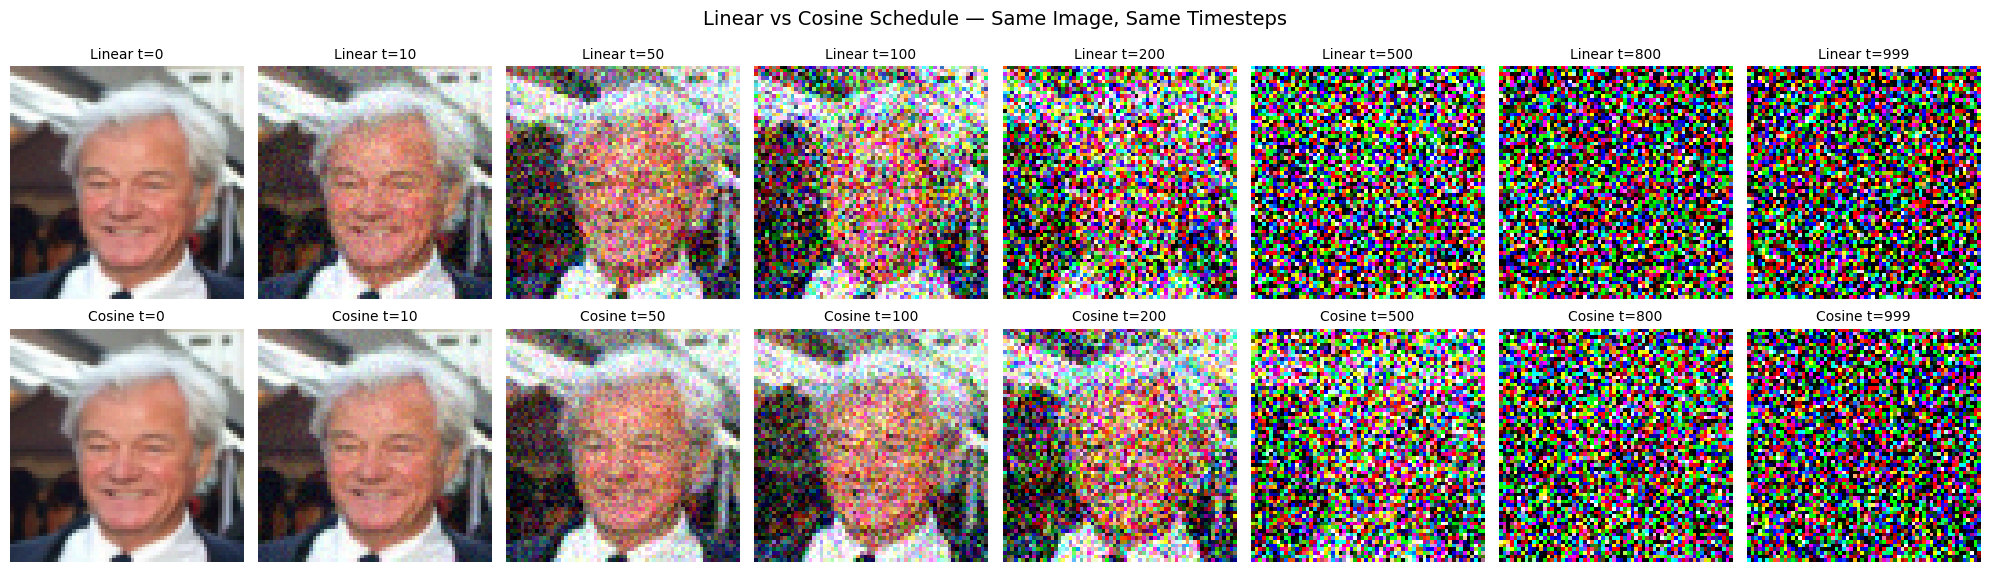

In [12]:
# [PLAY] compare linear vs cosine for the same image at the same steps
def prepare_schedule(betas_schedule, T, device):
    betas = betas_schedule.to(device)
    alphas = 1 - betas
    alphas_bar = torch.cumprod(alphas, dim=0)
    return torch.sqrt(alphas_bar), torch.sqrt(1 - alphas_bar)

# Cosine schedule
cosine_betas_tensor = cosine_betas(T)
sqrt_ab_cos, sqrt_1m_cos = prepare_schedule(cosine_betas_tensor, T, device)

# Linear schedule (already have sqrt_alphas_bar, sqrt_one_minus_alphas_bar)
sqrt_ab_lin = sqrt_alphas_bar
sqrt_1m_lin = sqrt_one_minus_alphas_bar

fig, axes = plt.subplots(2, len(sample_steps), figsize=(20, 6))

for i, t in enumerate(sample_steps):
    t_tensor = torch.tensor([t], device=device)

    # Linear
    xt_lin, _ = forward_diffusion(x0, t_tensor, sqrt_ab_lin, sqrt_1m_lin)
    axes[0, i].imshow(xt_lin[0].cpu().permute(1, 2, 0).clamp(0, 1))
    axes[0, i].set_title(f"Linear t={t}", fontsize=10)
    axes[0, i].axis("off")

    # Cosine
    xt_cos, _ = forward_diffusion(x0, t_tensor, sqrt_ab_cos, sqrt_1m_cos)
    axes[1, i].imshow(xt_cos[0].cpu().permute(1, 2, 0).clamp(0, 1))
    axes[1, i].set_title(f"Cosine t={t}", fontsize=10)
    axes[1, i].axis("off")

plt.suptitle("Linear vs Cosine Schedule — Same Image, Same Timesteps", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Linear vs Cosine Noise Schedule

The cosine schedule is designed to preserve image information longer during the diffusion process. In this section, we compare the two schedules using:

- Noise schedule (βₜ)
- Signal retention (ᾱₜ)
- Signal half-life (ᾱₜ ≈ 0.5)

The corresponding visual comparison of image degradation is presented in the next section.

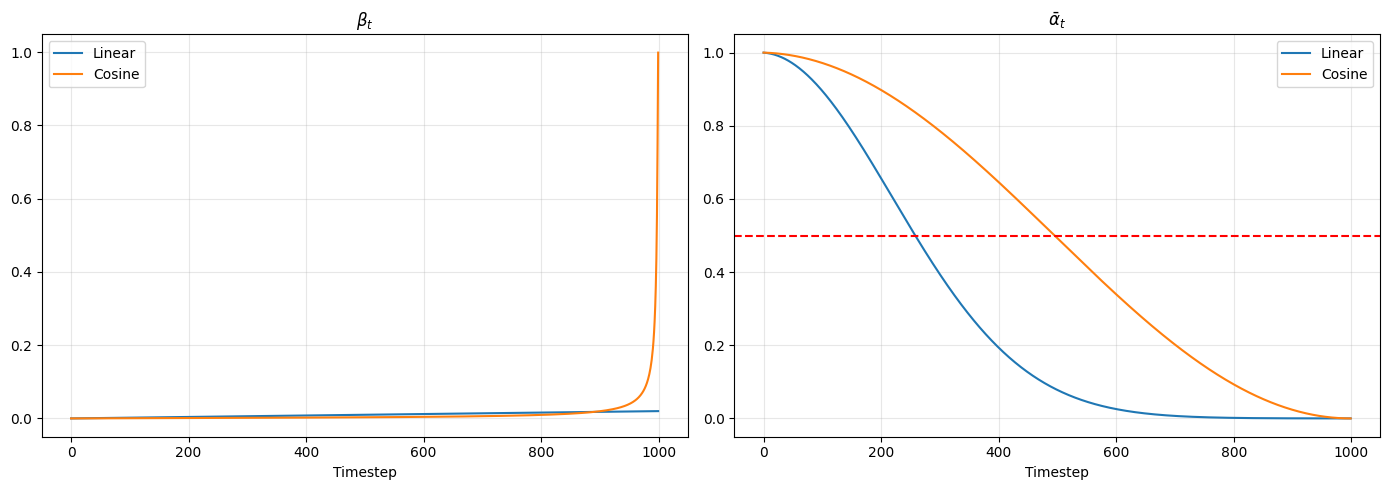

In [13]:
# ===== Compare Linear and Cosine Schedules =====

linear_betas = torch.linspace(beta_start, beta_end, T)

cosine_betas_tensor = cosine_betas(T)

linear_alphas = 1 - linear_betas
linear_alpha_bar = torch.cumprod(linear_alphas, dim=0)

cosine_alphas = 1 - cosine_betas_tensor
cosine_alpha_bar = torch.cumprod(cosine_alphas, dim=0)

fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Beta
ax[0].plot(linear_betas.cpu(), label="Linear")
ax[0].plot(cosine_betas_tensor.cpu(), label="Cosine")
ax[0].set_title(r"$\beta_t$")
ax[0].set_xlabel("Timestep")
ax[0].legend()
ax[0].grid(alpha=0.3)

# Alpha_bar
ax[1].plot(linear_alpha_bar.cpu(), label="Linear")
ax[1].plot(cosine_alpha_bar.cpu(), label="Cosine")
ax[1].axhline(0.5,color='red',linestyle='--')
ax[1].set_title(r"$\bar{\alpha}_t$")
ax[1].set_xlabel("Timestep")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
linear_half = torch.argmin(torch.abs(linear_alpha_bar-0.5)).item()
cosine_half = torch.argmin(torch.abs(cosine_alpha_bar-0.5)).item()

print(f"Linear schedule half-life (ᾱ≈0.5): t = {linear_half}")
print(f"Cosine schedule half-life (ᾱ≈0.5): t = {cosine_half}")

Linear schedule half-life (ᾱ≈0.5): t = 258
Cosine schedule half-life (ᾱ≈0.5): t = 495


## 7. DDPM Training Objective

The neural network is trained to predict the Gaussian noise added to an image rather than reconstructing the image directly.

The training objective minimizes the mean squared error between the predicted and true noise.

In [15]:
def ddpm_loss(model, x0, t, sqrt_alphas_bar, sqrt_one_minus_alphas_bar):
    """
    Simplified ELBO loss: predict the noise.

    Args:
        model: noise predictor ε_θ(x_t, t)
        x0: clean image [B, C, H, W]
        t: random timesteps [B]
    """
    # Forward: add noise to x0
    noise = torch.randn_like(x0)
    xt = sqrt_alphas_bar[t].view(-1, 1, 1, 1) * x0 + \
         sqrt_one_minus_alphas_bar[t].view(-1, 1, 1, 1) * noise

    # Predict noise
    noise_pred = model(xt, t)

    # Simple MSE loss
    loss = torch.nn.functional.mse_loss(noise_pred, noise)
    return loss

## 8. Closed-form Numerical Verification

The theoretical forward diffusion equation predicts the mean and variance of the noisy image distribution.

We verify this experimentally by generating many noisy samples at a fixed timestep and comparing the empirical statistics with the theoretical values.

In [16]:
# ===== Closed-form Verification =====

t = 500
num_samples = 1000

x0 = x[0:1]

sqrt_alpha_t = sqrt_alphas_bar[t]
sqrt_one_minus_t = sqrt_one_minus_alphas_bar[t]

samples = []

for _ in range(num_samples):
    noise = torch.randn_like(x0)
    xt = sqrt_alpha_t*x0 + sqrt_one_minus_t*noise
    samples.append(xt)

samples = torch.cat(samples, dim=0)

empirical_mean = samples.mean(dim=0)
empirical_var = samples.var(dim=0)

theoretical_mean = sqrt_alpha_t*x0
theoretical_var = (sqrt_one_minus_t**2)

print("Mean Error:",
      (empirical_mean-theoretical_mean).abs().mean().item())

print("Empirical Variance:",
      empirical_var.mean().item())

print("Theoretical Variance:",
      theoretical_var.item())

Mean Error: 0.024317346513271332
Empirical Variance: 0.9218664765357971
Theoretical Variance: 0.9222033619880676


## 9. Discussion

The Gaussian noise added at every diffusion step is independent. Since the sum of independent Gaussian variables is also Gaussian, all intermediate noise additions can be combined into a single Gaussian sample.

This allows the noisy image xₜ to be generated directly from the clean image x₀ without simulating every intermediate diffusion step, making training significantly more efficient while preserving the correct probability distribution.